In [4]:
# BLOCK 1: Imports and Setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline
import joblib

# Create a timestamp for the results directory
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_dir = f"results_{timestamp}"
os.makedirs(results_dir, exist_ok=True)

print("Setup complete and results directory created.")

# BLOCK 2: Data Generation Functions
def generate_simulation_data(num_simulations=1000, random_state=42):
    """
    Generate synthetic EEG simulation data.
    
    Parameters:
        num_simulations (int): Number of simulations to generate
        random_state (int): Random seed for reproducibility
    
    Returns:
        pd.DataFrame: DataFrame containing simulation parameters
    """
    np.random.seed(random_state)
    
    # Simulation parameters
    data = {
        'simulation_id': range(1, num_simulations + 1),
        'duration': np.random.uniform(10, 60, num_simulations),  # minutes
        'sampling_rate': np.random.choice([128, 256, 512, 1024], num_simulations),  # Hz
        'num_channels': np.random.randint(4, 32, num_simulations),
        'baseline_amplitude': np.random.uniform(5, 50, num_simulations),  # microvolts
        'noise_level': np.random.uniform(0.1, 2.0, num_simulations),
        'has_seizure': np.random.choice([0, 1], num_simulations, p=[0.7, 0.3]),
    }
    
    df = pd.DataFrame(data)
    
    # For simulations with seizures, add seizure parameters
    seizure_mask = df['has_seizure'] == 1
    num_seizures = seizure_mask.sum()
    
    # Initialize seizure columns with NaN
    df['seizure_count'] = np.nan
    df['time_to_first_seizure'] = np.nan
    df['seizure_duration'] = np.nan
    df['seizure_amplitude'] = np.nan
    df['seizure_frequency'] = np.nan
    
    # Fill seizure data only for rows with seizures
    df.loc[seizure_mask, 'seizure_count'] = np.random.randint(1, 5, num_seizures)
    
    # Time to first seizure (in seconds)
    max_times = df.loc[seizure_mask, 'duration'] * 60 * 0.8  # 80% of total duration max
    df.loc[seizure_mask, 'time_to_first_seizure'] = np.random.uniform(
        60, max_times, num_seizures
    )
    
    df.loc[seizure_mask, 'seizure_duration'] = np.random.uniform(
        5, 120, num_seizures
    )  # seconds
    
    df.loc[seizure_mask, 'seizure_amplitude'] = df.loc[seizure_mask, 'baseline_amplitude'] * np.random.uniform(
        2, 10, num_seizures
    )
    
    df.loc[seizure_mask, 'seizure_frequency'] = np.random.uniform(
        3, 20, num_seizures
    )  # Hz
    
    return df

def generate_eeg_features(simulation_data, random_state=42):
    """
    Generate EEG features based on simulation parameters.
    
    Parameters:
        simulation_data (pd.DataFrame): DataFrame with simulation parameters
        random_state (int): Random seed for reproducibility
    
    Returns:
        pd.DataFrame: DataFrame containing EEG features
    """
    np.random.seed(random_state)
    
    num_simulations = len(simulation_data)
    
    # Statistical features
    features = pd.DataFrame()
    features['simulation_id'] = simulation_data['simulation_id']
    
    # Basic statistical features
    features['mean_amplitude'] = np.where(
        simulation_data['has_seizure'] == 1,
        simulation_data['baseline_amplitude'] * np.random.uniform(1.2, 1.8, num_simulations),
        simulation_data['baseline_amplitude'] * np.random.uniform(0.8, 1.2, num_simulations)
    )
    
    features['std_amplitude'] = np.where(
        simulation_data['has_seizure'] == 1,
        simulation_data['baseline_amplitude'] * np.random.uniform(0.4, 1.2, num_simulations),
        simulation_data['baseline_amplitude'] * np.random.uniform(0.1, 0.4, num_simulations)
    )
    
    # Frequency domain features
    features['delta_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.5, 2.0, num_simulations),
        np.random.uniform(0.1, 0.8, num_simulations)
    )
    
    features['theta_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.8, 2.5, num_simulations),
        np.random.uniform(0.2, 1.0, num_simulations)
    )
    
    features['alpha_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.2, 0.8, num_simulations),
        np.random.uniform(0.8, 2.0, num_simulations)
    )
    
    features['beta_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(1.5, 3.0, num_simulations),
        np.random.uniform(0.5, 1.5, num_simulations)
    )
    
    features['gamma_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(2.0, 5.0, num_simulations),
        np.random.uniform(0.3, 1.0, num_simulations)
    )
    
    # Complexity measures
    features['entropy'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.1, 0.6, num_simulations),
        np.random.uniform(0.5, 0.9, num_simulations)
    )
    
    features['line_length'] = np.where(
        simulation_data['has_seizure'] == 1,
        simulation_data['baseline_amplitude'] * np.random.uniform(1.5, 3.0, num_simulations),
        simulation_data['baseline_amplitude'] * np.random.uniform(0.5, 1.5, num_simulations)
    )
    
    # Connectivity features (mimicking cross-channel correlations)
    features['mean_correlation'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.6, 0.95, num_simulations),
        np.random.uniform(0.3, 0.7, num_simulations)
    )
    
    features['correlation_std'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.05, 0.2, num_simulations),
        np.random.uniform(0.1, 0.3, num_simulations)
    )
    
    # Make features dependent on seizure parameters for simulations with seizures
    seizure_mask = simulation_data['has_seizure'] == 1
    
    if seizure_mask.sum() > 0:
        # Adjust features based on time to seizure
        time_to_seizure = simulation_data.loc[seizure_mask, 'time_to_first_seizure'].values
        max_time = np.max(time_to_seizure)
        
        # Normalized time (0-1)
        norm_time = time_to_seizure / max_time if max_time > 0 else np.zeros_like(time_to_seizure)
        
        # The closer to seizure, the more abnormal the features
        proximity_factor = 1 - norm_time
        
        # Adjust features based on proximity to seizure
        for feature in ['delta_power', 'theta_power', 'beta_power', 'gamma_power', 'line_length']:
            base_values = features.loc[seizure_mask, feature].values
            features.loc[seizure_mask, feature] = base_values * (1 + proximity_factor * 0.5)
        
        for feature in ['alpha_power', 'entropy']:
            base_values = features.loc[seizure_mask, feature].values
            features.loc[seizure_mask, feature] = base_values * (1 - proximity_factor * 0.3)
        
        # Add more complex features based on seizure parameters
        seizure_amplitude = simulation_data.loc[seizure_mask, 'seizure_amplitude'].values
        seizure_frequency = simulation_data.loc[seizure_mask, 'seizure_frequency'].values
        
        features.loc[seizure_mask, 'amplitude_ratio'] = (
            seizure_amplitude / simulation_data.loc[seizure_mask, 'baseline_amplitude'].values
        )
        
        features.loc[seizure_mask, 'frequency_change'] = (
            seizure_frequency / np.random.uniform(8, 12, len(seizure_frequency))
        )
    
    else:
        # Handle the case where there are no seizures
        features['amplitude_ratio'] = np.random.uniform(0.8, 1.2, num_simulations)
        features['frequency_change'] = np.random.uniform(0.9, 1.1, num_simulations)
    
    # Add some noise to all features
    for col in features.columns:
        if col != 'simulation_id':
            features[col] = features[col] * np.random.normal(1, 0.05, num_simulations)
    
    return features

print("Data generation functions defined.")

# BLOCK 3: Generate Data
def generate_dataset(num_simulations=10000, random_state=42):
    """
    Generate a full dataset with simulation parameters, EEG features, and targets.
    
    Parameters:
        num_simulations (int): Number of simulations to generate
        random_state (int): Random seed for reproducibility
    
    Returns:
        tuple:
            - pd.DataFrame: Simulation parameters
            - pd.DataFrame: EEG features
            - pd.DataFrame: Target variables
    """
    # Generate simulation data
    print(f"Generating {num_simulations} simulations...")
    simulation_data = generate_simulation_data(num_simulations, random_state)
    
    # Generate EEG features based on simulation parameters
    print("Generating EEG features...")
    features = generate_eeg_features(simulation_data, random_state)
    
    # Create target variables
    print("Creating target variables...")
    targets = pd.DataFrame()
    targets['simulation_id'] = simulation_data['simulation_id']
    targets['has_seizure'] = simulation_data['has_seizure']
    
    # For simulations with seizures, add time to seizure in seconds
    targets['time_to_seizure'] = np.nan
    seizure_mask = simulation_data['has_seizure'] == 1
    targets.loc[seizure_mask, 'time_to_seizure'] = simulation_data.loc[
        seizure_mask, 'time_to_first_seizure'
    ]
    
    return simulation_data, features, targets

# Generate data
simulation_data, features, targets = generate_dataset(num_simulations=1000)

# Check that data was created correctly
print(f"Simulation data shape: {simulation_data.shape}")
print(f"Features shape: {features.shape}")
print(f"Targets shape: {targets.shape}")

# Display a few rows of each
print("\nSimulation data sample:")
display(simulation_data.head())

print("\nFeatures sample:")
display(features.head())

print("\nTargets sample:")
display(targets.head())

# BLOCK 4: Data Preprocessing
def preprocess_data(features, targets):
    """
    Preprocess the features and targets.
    
    Parameters:
        features (pd.DataFrame): Feature matrix
        targets (pd.DataFrame): Target variables
    
    Returns:
        tuple:
            - pd.DataFrame: Processed features
            - pd.DataFrame: Processed targets
    """
    print("Preprocessing data...")
    
    # Make a copy to avoid modifying the original
    features_processed = features.copy()
    targets_processed = targets.copy()
    
    # Remove ID column for modeling but keep for reference
    features_id = features_processed['simulation_id']
    features_processed = features_processed.drop(columns=['simulation_id'])
    
    # For time_to_seizure prediction, we only use rows where has_seizure=1
    # but we'll prepare that subset in the training function
    
    # Check for missing values
    print(f"Missing values in features: {features_processed.isna().sum().sum()}")
    print(f"Missing values in targets: {targets_processed.isna().sum().sum()}")
    
    # Fill missing values in features if any
    if features_processed.isna().sum().sum() > 0:
        features_processed = features_processed.fillna(features_processed.mean())
    
    # Check for outliers (simplified approach using IQR)
    Q1 = features_processed.quantile(0.25)
    Q3 = features_processed.quantile(0.75)
    IQR = Q3 - Q1
    
    outlier_mask = ((features_processed < (Q1 - 1.5 * IQR)) | 
                    (features_processed > (Q3 + 1.5 * IQR))).any(axis=1)
    
    print(f"Number of potential outliers detected: {outlier_mask.sum()}")
    
    # For this example, we'll keep outliers but in a real application,
    # you might want to handle them differently
    
    # Add back the ID for reference
    features_processed.insert(0, 'simulation_id', features_id)
    
    return features_processed, targets_processed

# Preprocess the data
features_processed, targets_processed = preprocess_data(features, targets)

# Display shapes after preprocessing
print(f"\nProcessed features shape: {features_processed.shape}")
print(f"Processed targets shape: {targets_processed.shape}")

# BLOCK 5: Data Splitting for Model Training
def prepare_for_training(features, targets):
    """
    Prepare processed data for model training by removing ID columns.
    
    Parameters:
        features (pd.DataFrame): Processed features
        targets (pd.DataFrame): Processed targets
    
    Returns:
        tuple:
            - pd.DataFrame: Features for modeling
            - pd.DataFrame: Targets for modeling
    """
    # Remove ID columns for modeling
    features_for_modeling = features.drop(columns=['simulation_id'])
    targets_for_modeling = targets.drop(columns=['simulation_id'])
    
    print(f"Features for modeling shape: {features_for_modeling.shape}")
    print(f"Targets for modeling shape: {targets_for_modeling.shape}")
    
    return features_for_modeling, targets_for_modeling

# Prepare data for training
features_for_modeling, targets_for_modeling = prepare_for_training(features_processed, targets_processed)

# BLOCK 6: Model Training Function
def train_seizure_prediction_models(features, targets, test_size=0.2, random_state=42):
    """
    Train models to predict seizure occurrence and onset time.
    
    Parameters:
        features (pd.DataFrame): Feature matrix
        targets (pd.DataFrame): Target variables (has_seizure, time_to_seizure)
        test_size (float): Proportion of data to use for testing
        random_state (int): Random seed for reproducibility
    
    Returns:
        tuple:
            - dict: Trained models
            - dict: Dictionary containing model performance metrics
    """
    # Debug: Check if features or targets are empty
    print(f"Features shape: {features.shape}")
    print(f"Targets shape: {targets.shape}")
    
    if features.shape[0] == 0 or targets.shape[0] == 0:
        raise ValueError("Features or targets DataFrame is empty. Check your data processing steps.")
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        features, targets, test_size=test_size, random_state=random_state
    )
    
    # Create classification model for seizure occurrence
    seizure_classifier = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=random_state))
    ])
    
    # Train seizure occurrence classifier
    print("Training seizure occurrence classifier...")
    seizure_classifier.fit(X_train, y_train['has_seizure'])
    
    # Predict on test set
    y_pred_seizure = seizure_classifier.predict(X_test)
    
    # Calculate metrics for seizure occurrence
    accuracy = accuracy_score(y_test['has_seizure'], y_pred_seizure)
    precision = precision_score(y_test['has_seizure'], y_pred_seizure)
    recall = recall_score(y_test['has_seizure'], y_pred_seizure)
    f1 = f1_score(y_test['has_seizure'], y_pred_seizure)
    
    print(f"Seizure Classifier Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    
    # Create regression model for seizure time prediction
    # Only use data points where seizures occur
    seizure_mask_train = y_train['has_seizure'] == 1
    seizure_mask_test = y_test['has_seizure'] == 1
    
    # Check if we have seizure data to train the regression model
    if seizure_mask_train.sum() > 0 and seizure_mask_test.sum() > 0:
        X_train_seizure = X_train[seizure_mask_train]
        y_train_seizure = y_train.loc[seizure_mask_train, 'time_to_seizure']
        
        X_test_seizure = X_test[seizure_mask_test]
        y_test_seizure = y_test.loc[seizure_mask_test, 'time_to_seizure']
        
        seizure_regressor = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', RandomForestRegressor(n_estimators=100, random_state=random_state))
        ])
        
        # Train seizure time predictor
        print("Training seizure time prediction model...")
        seizure_regressor.fit(X_train_seizure, y_train_seizure)
        
        # Predict on test set
        y_pred_time = seizure_regressor.predict(X_test_seizure)
        
        # Calculate metrics for time prediction
        mse = mean_squared_error(y_test_seizure, y_pred_time)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test_seizure, y_pred_time)
        r2 = r2_score(y_test_seizure, y_pred_time)
        
        print(f"Seizure Time Predictor Metrics:")
        print(f"  Mean Squared Error: {mse:.4f}")
        print(f"  Root Mean Squared Error: {rmse:.4f}")
        print(f"  Mean Absolute Error: {mae:.4f}")
        print(f"  R² Score: {r2:.4f}")
    else:
        print("Not enough seizure data to train the regression model")
        seizure_regressor = None
        rmse = mae = r2 = None
    
    # Store models and metrics
    models = {
        'seizure_classifier': seizure_classifier,
        'seizure_regressor': seizure_regressor
    }
    
    metrics = {
        'classification': {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1
        },
        'regression': {
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        }
    }
    
    return models, metrics

# BLOCK 7: Train Models
# Train models
print("Training models...")
models, metrics = train_seizure_prediction_models(features_for_modeling, targets_for_modeling)

# BLOCK 8: Visualize Results
def visualize_results(features, targets, models, results_dir):
    """
    Create visualizations for model results.
    
    Parameters:
        features (pd.DataFrame): Feature matrix
        targets (pd.DataFrame): Target variables
        models (dict): Dictionary of trained models
        results_dir (str): Directory to save results
    """
    # Split data again for visualization
    X_train, X_test, y_train, y_test = train_test_split(
        features, targets, test_size=0.2, random_state=42
    )
    
    # Seizure classifier predictions
    y_pred_proba = models['seizure_classifier'].predict_proba(X_test)[:, 1]
    y_pred = models['seizure_classifier'].predict(X_test)
    
    # Create confusion matrix
    cm = confusion_matrix(y_test['has_seizure'], y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Seizure', 'Seizure'],
                yticklabels=['No Seizure', 'Seizure'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Seizure Prediction')
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'confusion_matrix.png'))
    plt.close()
    
    # ROC curve for seizure classification
    from sklearn.metrics import roc_curve, roc_auc_score
    fpr, tpr, _ = roc_curve(y_test['has_seizure'], y_pred_proba)
    auc = roc_auc_score(y_test['has_seizure'], y_pred_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Seizure Prediction')
    plt.legend(loc='lower right')
    plt.savefig(os.path.join(results_dir, 'roc_curve.png'))
    plt.close()
    
    # Histogram of predicted probabilities by actual class
    plt.figure(figsize=(10, 6))
    sns.histplot(y_pred_proba[y_test['has_seizure'] == 0], 
                 color='green', alpha=0.5, bins=20, label='No Seizure')
    sns.histplot(y_pred_proba[y_test['has_seizure'] == 1], 
                 color='red', alpha=0.5, bins=20, label='Seizure')
    plt.xlabel('Predicted Probability of Seizure')
    plt.ylabel('Count')
    plt.title('Distribution of Predicted Probabilities by Actual Class')
    plt.legend()
    plt.savefig(os.path.join(results_dir, 'probability_distribution.png'))
    plt.close()
    
    # Feature importance for seizure classifier
    feature_names = features.columns
    importances = models['seizure_classifier'].named_steps['classifier'].feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(12, 8))
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.title('Feature Importance for Seizure Prediction')
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'feature_importance.png'))
    plt.close()
    
    # For seizure time predictor, if available
    if models['seizure_regressor'] is not None:
        # Only use data with seizures
        seizure_mask = y_test['has_seizure'] == 1
        X_test_seizure = X_test[seizure_mask]
        y_test_seizure = y_test.loc[seizure_mask, 'time_to_seizure']
        
        if len(X_test_seizure) > 0:
            y_pred_time = models['seizure_regressor'].predict(X_test_seizure)
            
            # Scatter plot of actual vs predicted seizure time
            plt.figure(figsize=(8, 8))
            plt.scatter(y_test_seizure, y_pred_time, alpha=0.6)
            plt.plot([0, max(y_test_seizure)], [0, max(y_test_seizure)], 'r--')
            plt.xlabel('Actual Time to Seizure (seconds)')
            plt.ylabel('Predicted Time to Seizure (seconds)')
            plt.title('Actual vs Predicted Time to Seizure')
            plt.savefig(os.path.join(results_dir, 'time_prediction.png'))
            plt.close()
            
            # Feature importance for seizure time predictor
            importances = models['seizure_regressor'].named_steps['regressor'].feature_importances_
            indices = np.argsort(importances)[::-1]
            
            plt.figure(figsize=(12, 8))
            plt.bar(range(len(importances)), importances[indices])
            plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
            plt.xlabel('Features')
            plt.ylabel('Importance')
            plt.title('Feature Importance for Seizure Time Prediction')
            plt.tight_layout()
            plt.savefig(os.path.join(results_dir, 'time_feature_importance.png'))
            plt.close()

# BLOCK 9: Save Models and Results
def save_results(models, metrics, simulation_data, features, targets, results_dir):
    """
    Save models, metrics, and data for future use.
    
    Parameters:
        models (dict): Dictionary of trained models
        metrics (dict): Dictionary of model metrics
        simulation_data (pd.DataFrame): Simulation parameters
        features (pd.DataFrame): Feature matrix
        targets (pd.DataFrame): Target variables
        results_dir (str): Directory to save results
    """
    # Save models
    joblib.dump(models, os.path.join(results_dir, 'models.joblib'))
    
    # Save metrics as JSON
    import json
    with open(os.path.join(results_dir, 'metrics.json'), 'w') as f:
        json.dump(metrics, f, indent=4)
    
    # Save data
    simulation_data.to_csv(os.path.join(results_dir, 'simulation_data.csv'), index=False)
    features.to_csv(os.path.join(results_dir, 'features.csv'), index=False)
    targets.to_csv(os.path.join(results_dir, 'targets.csv'), index=False)
    
    print(f"All results saved to {results_dir}")

# BLOCK 10: Main Function
def main():
    """
    Run the full seizure prediction pipeline.
    """
    # Generate dataset
    sim_data, feat, targ = generate_dataset(num_simulations=1000)
    
    # Preprocess data
    feat_processed, targ_processed = preprocess_data(feat, targ)
    
    # Prepare for training (remove IDs)
    feat_model, targ_model = prepare_for_training(feat_processed, targ_processed)
    
    # Debug: Check features and targets before model training
    print(f"Before model training - Features shape: {feat_model.shape}")
    print(f"Before model training - Targets shape: {targ_model.shape}")
    print(f"Features columns: {feat_model.columns.tolist()}")
    print(f"Targets columns: {targ_model.columns.tolist()}")
    
    # Train models
    models, metrics = train_seizure_prediction_models(feat_model, targ_model)
    
    # Visualize results
    visualize_results(feat_model, targ_model, models, results_dir)
    
    # Save results
    save_results(models, metrics, sim_data, feat_processed, targ_processed, results_dir)
    
    return models, results_dir

# BLOCK 11: Example Usage
# Run the main pipeline
if __name__ == "__main__":
    models, results_dir = main()
    
    # Example: using the model for prediction with new data
    print("\nExample: Predicting with new simulation parameters")
    
    # Generate a single new simulation
    new_sim = generate_simulation_data(num_simulations=1)
    new_features = generate_eeg_features(new_sim)
    
    # Preprocess and prepare for prediction
    new_features_id = new_features['simulation_id'].copy()
    new_features = new_features.drop(columns=['simulation_id'])
    
    # Make predictions
    seizure_prob = models['seizure_classifier'].predict_proba(new_features)[:, 1][0]
    seizure_pred = models['seizure_classifier'].predict(new_features)[0]
    
    print(f"Predicted seizure probability: {seizure_prob:.4f}")
    print(f"Seizure predicted: {'Yes' if seizure_pred == 1 else 'No'}")
    
    # If seizure predicted and we have a regression model, predict time
    if seizure_pred == 1 and models['seizure_regressor'] is not None:
        time_pred = models['seizure_regressor'].predict(new_features)[0]
        print(f"Predicted time to seizure: {time_pred:.2f} seconds")
    
    print("\nPipeline execution complete!")

Setup complete and results directory created.
Data generation functions defined.
Generating 1000 simulations...
Generating EEG features...
Creating target variables...
Simulation data shape: (1000, 12)
Features shape: (1000, 14)
Targets shape: (1000, 3)

Simulation data sample:


,simulation_id,duration,sampling_rate,num_channels,baseline_amplitude,noise_level,has_seizure,seizure_count,time_to_first_seizure,seizure_duration,seizure_amplitude,seizure_frequency
0,1,28.727006,512,19,12.411786,0.576697,0,NaN,NaN,NaN,NaN,NaN
1,2,57.535715,1024,5,19.859678,1.384450,1,3.0,1790.125843,17.007767,138.876888,10.705547
2,3,46.599697,256,9,39.053818,1.442597,0,NaN,NaN,NaN,NaN,NaN
3,4,39.932924,1024,31,28.372364,1.259014,0,NaN,NaN,NaN,NaN,NaN
4,5,17.800932,1024,24,14.219657,0.694524,0,NaN,NaN,NaN,NaN,NaN



Features sample:


,simulation_id,mean_amplitude,std_amplitude,delta_power,theta_power,alpha_power,beta_power,gamma_power,entropy,line_length,mean_correlation,correlation_std,amplitude_ratio,frequency_change
0,1,11.580181,4.217382,0.372776,0.231919,1.890812,1.058029,0.991423,0.624306,17.662103,0.496478,0.263996,NaN,NaN
1,2,31.531723,11.461751,2.017747,1.344272,0.590807,2.389162,2.824703,0.136347,40.402663,0.757333,0.069858,7.275621,0.941362
2,3,46.982679,6.218981,0.653386,0.861599,1.775969,1.020945,0.989348,0.722314,56.245303,0.346139,0.254120,NaN,NaN
3,4,30.692953,7.839789,0.322606,0.777717,1.255060,0.823014,0.521522,0.547231,25.576831,0.342147,0.111348,NaN,NaN
4,5,17.013274,3.712072,0.766540,0.469126,1.556091,0.558879,0.296936,0.592026,21.702570,0.591545,0.133274,NaN,NaN



Targets sample:


,simulation_id,has_seizure,time_to_seizure
0,1,0,NaN
1,2,1,1790.125843
2,3,0,NaN
3,4,0,NaN
4,5,0,NaN


Preprocessing data...
Missing values in features: 1442
Missing values in targets: 721
Number of potential outliers detected: 279

Processed features shape: (1000, 14)
Processed targets shape: (1000, 3)
Features for modeling shape: (1000, 13)
Targets for modeling shape: (1000, 2)
Training models...
Features shape: (1000, 13)
Targets shape: (1000, 2)
Training seizure occurrence classifier...
Seizure Classifier Metrics:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
Training seizure time prediction model...
Seizure Time Predictor Metrics:
  Mean Squared Error: 269282.6937
  Root Mean Squared Error: 518.9246
  Mean Absolute Error: 434.3776
  R² Score: 0.2330
Generating 1000 simulations...
Generating EEG features...
Creating target variables...
Preprocessing data...
Missing values in features: 1442
Missing values in targets: 721
Number of potential outliers detected: 279
Features for modeling shape: (1000, 13)
Targets for modeling shape: (1000, 2)
Before model tr

**Library Imports, Data Generation, Data Preprocessing, Data Splitting**

Step 1, Action: [ 1.  40.   1.5], SNR: -9.29 dB
Step 2, Action: [ 3.  42.   1.5], SNR: -9.23 dB
Step 3, Action: [ 5.  44.   1.5], SNR: -8.98 dB
Step 4, Action: [ 7.  46.   1.5], SNR: -8.75 dB
Step 5, Action: [ 9.  48.   1.5], SNR: -8.53 dB
Step 6, Action: [11.  50.   1.5], SNR: -8.30 dB
Step 7, Action: [13.  52.   1.5], SNR: -8.10 dB
Step 8, Action: [15.  54.   1.5], SNR: -7.91 dB
Step 9, Action: [17.  56.   1.5], SNR: -7.69 dB
Step 10, Action: [19.  58.   1.5], SNR: -7.44 dB


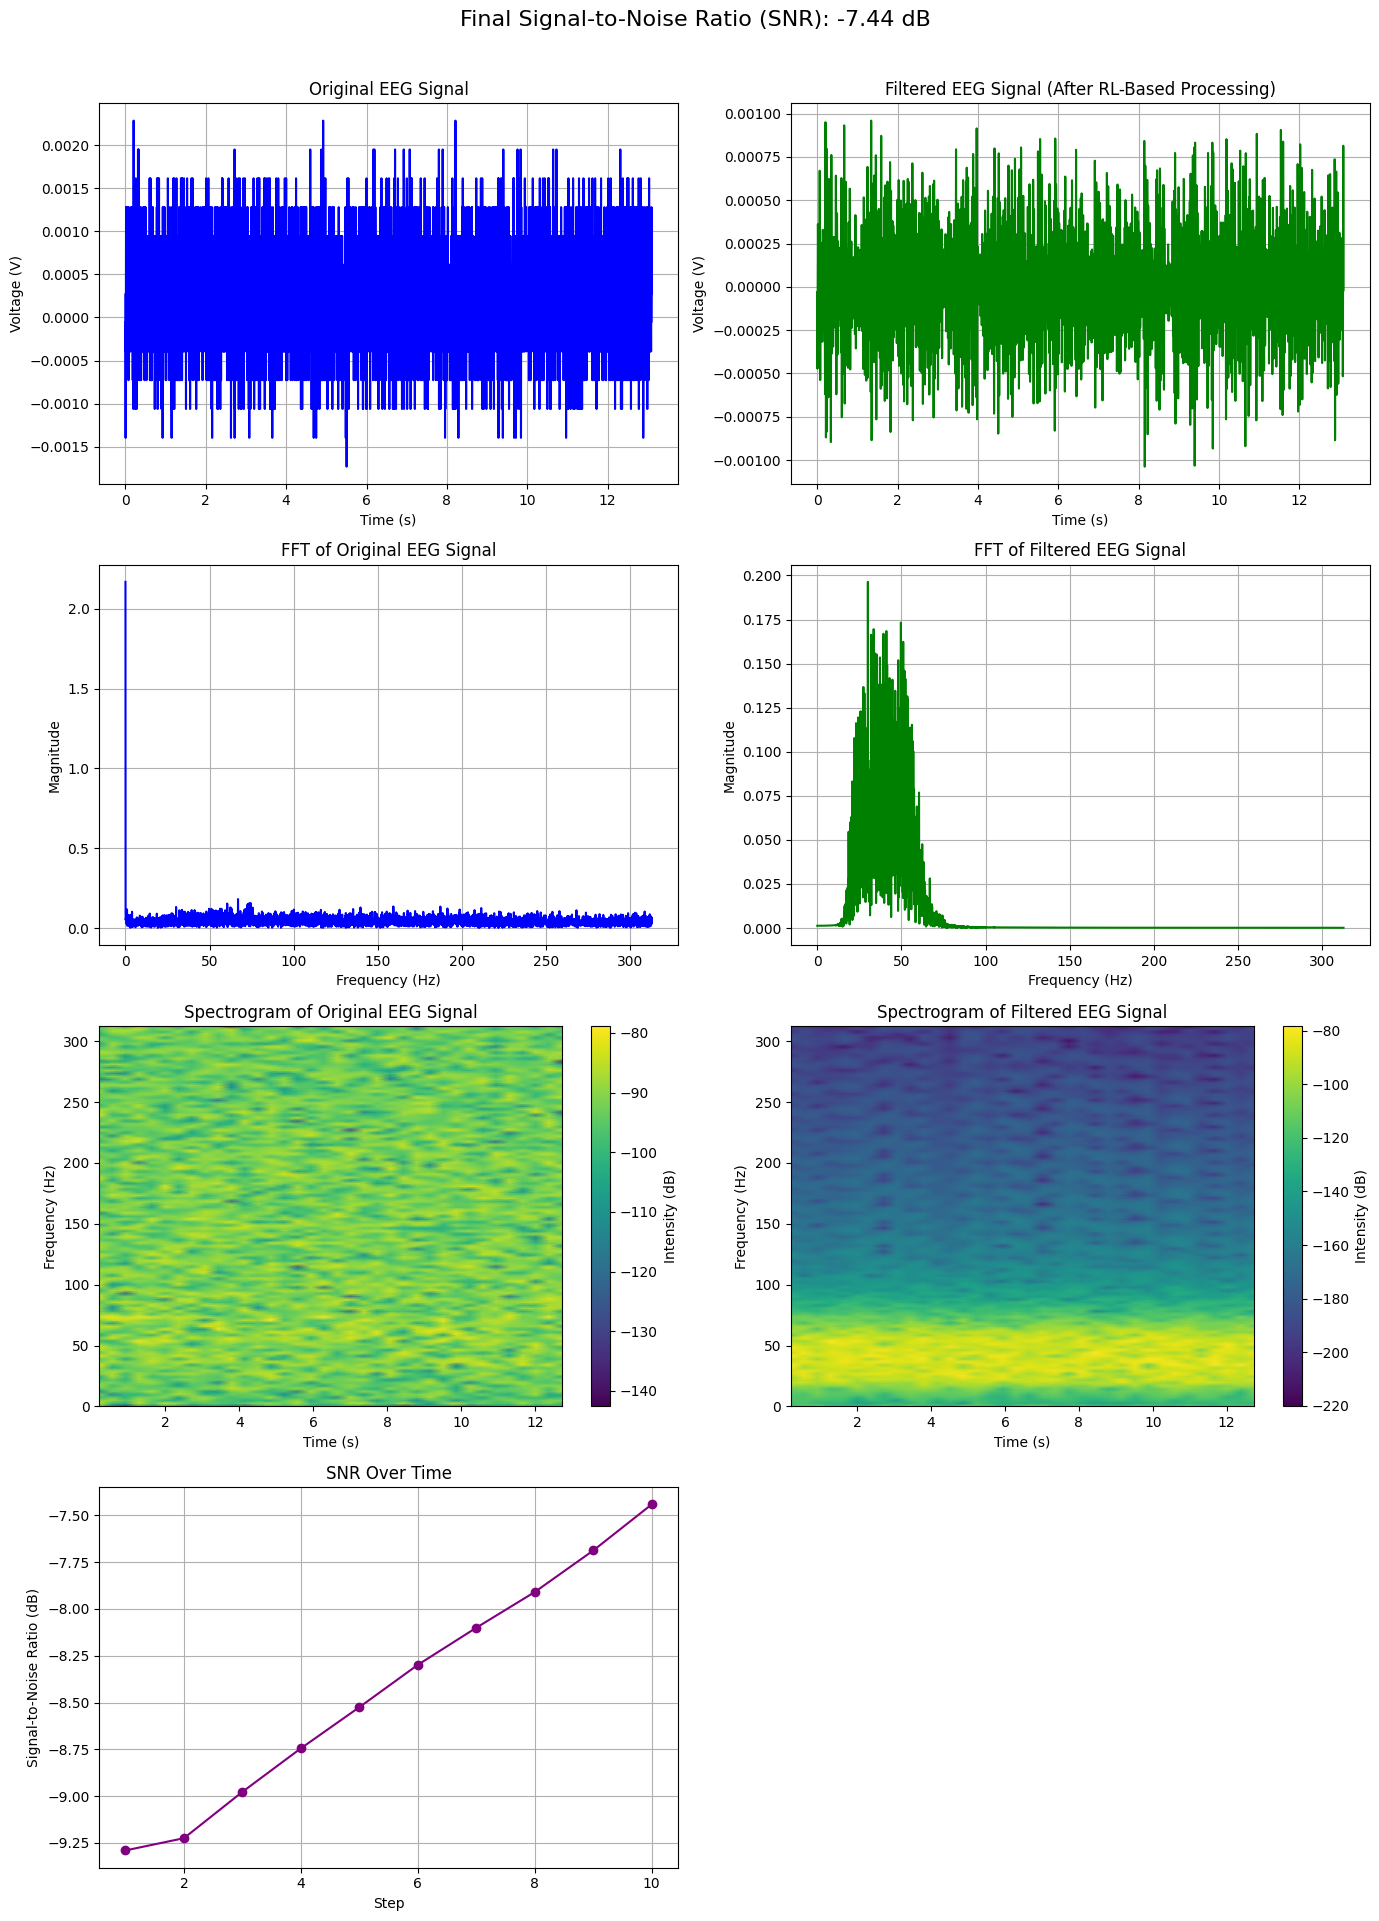

Data generation functions defined.
Preprocessing data...
Missing values in features: 1442
Missing values in targets: 721
Number of potential outliers detected: 279

Processed features shape: (1000, 14)
Processed targets shape: (1000, 3)
Features for modeling shape: (1000, 13)
Targets for modeling shape: (1000, 2)


In [5]:
import os
import time
import json
import joblib
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

######################################################################################################################################################################
# RL Environment for EEG Filtering
from scipy import signal
import gym
from gym import spaces
from scipy.stats import entropy, wasserstein_distance
from scipy.signal import welch

# Load EEG signal
fs = 625.34  
data = pd.read_csv('AD2Oscillascope60secrec.csv', comment='#')
channel1 = data['Channel 1 (V)'].values
time_axis = np.arange(len(channel1)) / fs  # Convert samples to time

# Define the RL environment
class SignalFilterEnv(gym.Env):
    def __init__(self, raw_signal, sample_rate):
        super(SignalFilterEnv, self).__init__()
        self.raw_signal = raw_signal
        self.fs = sample_rate
        self.signal_length = len(raw_signal)
        
        # Define action and observation space
        self.action_space = spaces.Box(
            low=np.array([0.1, 0.2, 0.1]),
            high=np.array([30.0, 100.0, 10.0]),
            dtype=np.float32
        )
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(self.signal_length,),
            dtype=np.float32
        )
        
        # Reference EEG signal properties (synthetic or real data)
        self.reference_psd = self.compute_psd(raw_signal)
    
    def compute_psd(self, signal):
        freqs, psd = welch(signal, self.fs, nperseg=1024)
        return psd
    
    def apply_filters(self, action):
        lowcut, highcut, gain = sorted(action[:2]) + [action[2]]
        nyq = 0.5 * self.fs
        lowcut, highcut = max(0.1, lowcut), max(lowcut + 1.0, highcut)
        
        b, a = signal.butter(4, [lowcut / nyq, highcut / nyq], btype='band')
        filtered_signal = signal.filtfilt(b, a, self.raw_signal)
        amplified_signal = np.clip(gain * filtered_signal, -np.max(self.raw_signal), np.max(self.raw_signal))
        return amplified_signal
    
    def calculate_reward(self, filtered_signal):
        psd_filtered = self.compute_psd(filtered_signal)
        spectral_distance = wasserstein_distance(self.reference_psd, psd_filtered)
        
        noise = self.raw_signal - filtered_signal
        noise_power = np.mean(noise**2)
        signal_power = np.mean(filtered_signal**2)
        snr = 10 * np.log10(signal_power / (noise_power + 1e-10))
        
        entropy_diff = abs(entropy(self.reference_psd) - entropy(psd_filtered))
        reward = snr - spectral_distance - entropy_diff  # Encourage SNR, discourage distortion
        return reward
    
    def step(self, action):
        filtered_signal = self.apply_filters(action)
        reward = self.calculate_reward(filtered_signal)
        return filtered_signal, reward, False, {}
    
    def reset(self):
        return self.raw_signal

# Initialize environment
env = SignalFilterEnv(channel1, fs)

# Run RL-based filtering over multiple steps
num_steps = 10
filtered_signals = []
snr_values = []

for step in range(num_steps):
    action = np.array([1.0 + step * 2, 40.0 + step * 2, 1.5])
    filtered_signal, reward, _, _ = env.step(action)
    filtered_signals.append(filtered_signal)
    snr_values.append(reward)
    print(f"Step {step + 1}, Action: {action}, SNR: {reward:.2f} dB")

# Compute FFT of original and filtered signals
def compute_fft(signal, fs):
    n = len(signal)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    fft_values = np.abs(np.fft.rfft(signal))
    return freqs, fft_values

final_filtered_signal = filtered_signals[-1]
freqs_raw, fft_raw = compute_fft(channel1, fs)
freqs_filtered, fft_filtered = compute_fft(final_filtered_signal, fs)

# Function to plot spectrogram
def plot_spectrogram(eeg_data, fs, title, ax):
    f, t, Sxx = signal.spectrogram(eeg_data, fs)
    im = ax.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')
    fig.colorbar(im, ax=ax, label='Intensity (dB)')

# Plot results
fig, axes = plt.subplots(4, 2, figsize=(14, 20))

# Original EEG signal
axes[0, 0].plot(time_axis, channel1, color='blue')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Voltage (V)')
axes[0, 0].set_title('Original EEG Signal')
axes[0, 0].grid()

# Filtered EEG signal (last step)
axes[0, 1].plot(time_axis, final_filtered_signal, color='green')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Voltage (V)')
axes[0, 1].set_title('Filtered EEG Signal (After RL-Based Processing)')
axes[0, 1].grid()

# FFT of original signal
axes[1, 0].plot(freqs_raw, fft_raw, color='blue')
axes[1, 0].set_xlabel('Frequency (Hz)')
axes[1, 0].set_ylabel('Magnitude')
axes[1, 0].set_title('FFT of Original EEG Signal')
axes[1, 0].grid()

# FFT of filtered signal
axes[1, 1].plot(freqs_filtered, fft_filtered, color='green')
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].set_ylabel('Magnitude')
axes[1, 1].set_title('FFT of Filtered EEG Signal')
axes[1, 1].grid()

# Spectrogram of original signal
plot_spectrogram(channel1, fs, 'Spectrogram of Original EEG Signal', axes[2, 0])

# Spectrogram of filtered signal
plot_spectrogram(final_filtered_signal, fs, 'Spectrogram of Filtered EEG Signal', axes[2, 1])

# Plot SNR over time
time_steps = np.arange(1, num_steps + 1)
axes[3, 0].plot(time_steps, snr_values, marker='o', color='purple')
axes[3, 0].set_xlabel('Step')
axes[3, 0].set_ylabel('Signal-to-Noise Ratio (dB)')
axes[3, 0].set_title('SNR Over Time')
axes[3, 0].grid()

# Empty subplot for symmetry
axes[3, 1].axis('off')

# Add overall SNR value to the plot
final_snr = env.calculate_reward(final_filtered_signal)
fig.text(0.5, 0.95, f'Final Signal-to-Noise Ratio (SNR): {final_snr:.2f} dB', ha='center', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.93])  # Adjust layout for the SNR text
plt.show()


######################################################################################################################################################################
# SIMULATED DATA GENERATION
def generate_simulation_data(num_simulations=1000, random_state=42):
    """
    Generate synthetic EEG simulation data.
    
    Parameters:
        num_simulations (int): Number of simulations to generate
        random_state (int): Random seed for reproducibility
    
    Returns:
        pd.DataFrame: DataFrame containing simulation parameters
    """
    np.random.seed(random_state)
    
    # Simulation parameters
    data = {
        'simulation_id': range(1, num_simulations + 1),
        'duration': np.random.uniform(10, 60, num_simulations),  # minutes
        'sampling_rate': np.random.choice([128, 256, 512, 1024], num_simulations),  # Hz
        'num_channels': np.random.randint(4, 32, num_simulations),
        'baseline_amplitude': np.random.uniform(5, 50, num_simulations),  # microvolts
        'noise_level': np.random.uniform(0.1, 2.0, num_simulations),
        'has_seizure': np.random.choice([0, 1], num_simulations, p=[0.7, 0.3]),
    }
    
    df = pd.DataFrame(data)
    
    # For simulations with seizures, add seizure parameters
    seizure_mask = df['has_seizure'] == 1
    num_seizures = seizure_mask.sum()
    
    # Initialize seizure columns with NaN
    df['seizure_count'] = np.nan
    df['time_to_first_seizure'] = np.nan
    df['seizure_duration'] = np.nan
    df['seizure_amplitude'] = np.nan
    df['seizure_frequency'] = np.nan
    
    # Fill seizure data only for rows with seizures
    df.loc[seizure_mask, 'seizure_count'] = np.random.randint(1, 5, num_seizures)
    
    # Time to first seizure (in seconds)
    max_times = df.loc[seizure_mask, 'duration'] * 60 * 0.8  # 80% of total duration max
    df.loc[seizure_mask, 'time_to_first_seizure'] = np.random.uniform(
        60, max_times, num_seizures
    )
    
    df.loc[seizure_mask, 'seizure_duration'] = np.random.uniform(
        5, 120, num_seizures
    )  # seconds
    
    df.loc[seizure_mask, 'seizure_amplitude'] = df.loc[seizure_mask, 'baseline_amplitude'] * np.random.uniform(
        2, 10, num_seizures
    )
    
    df.loc[seizure_mask, 'seizure_frequency'] = np.random.uniform(
        3, 20, num_seizures
    )  # Hz
    
    return df

def generate_eeg_features(simulation_data, random_state=42):
    """
    Generate EEG features based on simulation parameters.
    
    Parameters:
        simulation_data (pd.DataFrame): DataFrame with simulation parameters
        random_state (int): Random seed for reproducibility
    
    Returns:
        pd.DataFrame: DataFrame containing EEG features
    """
    np.random.seed(random_state)
    
    num_simulations = len(simulation_data)
    
    # Statistical features
    features = pd.DataFrame()
    features['simulation_id'] = simulation_data['simulation_id']
    
    # Basic statistical features
    features['mean_amplitude'] = np.where(
        simulation_data['has_seizure'] == 1,
        simulation_data['baseline_amplitude'] * np.random.uniform(1.2, 1.8, num_simulations),
        simulation_data['baseline_amplitude'] * np.random.uniform(0.8, 1.2, num_simulations)
    )
    
    features['std_amplitude'] = np.where(
        simulation_data['has_seizure'] == 1,
        simulation_data['baseline_amplitude'] * np.random.uniform(0.4, 1.2, num_simulations),
        simulation_data['baseline_amplitude'] * np.random.uniform(0.1, 0.4, num_simulations)
    )
    
    # Frequency domain features
    features['delta_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.5, 2.0, num_simulations),
        np.random.uniform(0.1, 0.8, num_simulations)
    )
    
    features['theta_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.8, 2.5, num_simulations),
        np.random.uniform(0.2, 1.0, num_simulations)
    )
    
    features['alpha_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.2, 0.8, num_simulations),
        np.random.uniform(0.8, 2.0, num_simulations)
    )
    
    features['beta_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(1.5, 3.0, num_simulations),
        np.random.uniform(0.5, 1.5, num_simulations)
    )
    
    features['gamma_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(2.0, 5.0, num_simulations),
        np.random.uniform(0.3, 1.0, num_simulations)
    )
    
    # Complexity measures
    features['entropy'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.1, 0.6, num_simulations),
        np.random.uniform(0.5, 0.9, num_simulations)
    )
    
    features['line_length'] = np.where(
        simulation_data['has_seizure'] == 1,
        simulation_data['baseline_amplitude'] * np.random.uniform(1.5, 3.0, num_simulations),
        simulation_data['baseline_amplitude'] * np.random.uniform(0.5, 1.5, num_simulations)
    )
    
    # Connectivity features (mimicking cross-channel correlations)
    features['mean_correlation'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.6, 0.95, num_simulations),
        np.random.uniform(0.3, 0.7, num_simulations)
    )
    
    features['correlation_std'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.05, 0.2, num_simulations),
        np.random.uniform(0.1, 0.3, num_simulations)
    )
    
    # Make features dependent on seizure parameters for simulations with seizures
    seizure_mask = simulation_data['has_seizure'] == 1
    
    if seizure_mask.sum() > 0:
        # Adjust features based on time to seizure
        time_to_seizure = simulation_data.loc[seizure_mask, 'time_to_first_seizure'].values
        max_time = np.max(time_to_seizure)
        
        # Normalized time (0-1)
        norm_time = time_to_seizure / max_time if max_time > 0 else np.zeros_like(time_to_seizure)
        
        # The closer to seizure, the more abnormal the features
        proximity_factor = 1 - norm_time
        
        # Adjust features based on proximity to seizure
        for feature in ['delta_power', 'theta_power', 'beta_power', 'gamma_power', 'line_length']:
            base_values = features.loc[seizure_mask, feature].values
            features.loc[seizure_mask, feature] = base_values * (1 + proximity_factor * 0.5)
        
        for feature in ['alpha_power', 'entropy']:
            base_values = features.loc[seizure_mask, feature].values
            features.loc[seizure_mask, feature] = base_values * (1 - proximity_factor * 0.3)
        
        # Add more complex features based on seizure parameters
        seizure_amplitude = simulation_data.loc[seizure_mask, 'seizure_amplitude'].values
        seizure_frequency = simulation_data.loc[seizure_mask, 'seizure_frequency'].values
        
        features.loc[seizure_mask, 'amplitude_ratio'] = (
            seizure_amplitude / simulation_data.loc[seizure_mask, 'baseline_amplitude'].values
        )
        
        features.loc[seizure_mask, 'frequency_change'] = (
            seizure_frequency / np.random.uniform(8, 12, len(seizure_frequency))
        )
    
    else:
        # Handle the case where there are no seizures
        features['amplitude_ratio'] = np.random.uniform(0.8, 1.2, num_simulations)
        features['frequency_change'] = np.random.uniform(0.9, 1.1, num_simulations)
    
    # Add some noise to all features
    for col in features.columns:
        if col != 'simulation_id':
            features[col] = features[col] * np.random.normal(1, 0.05, num_simulations)
    
    return features

print("Data generation functions defined.")


######################################################################################################################################################################
# DATA PREPROCESSING
def preprocess_data(features, targets):
    """
    Preprocess the features and targets.
    
    Parameters:
        features (pd.DataFrame): Feature matrix
        targets (pd.DataFrame): Target variables
    
    Returns:
        tuple:
            - pd.DataFrame: Processed features
            - pd.DataFrame: Processed targets
    """
    print("Preprocessing data...")
    
    # Make a copy to avoid modifying the original
    features_processed = features.copy()
    targets_processed = targets.copy()
    
    # Remove ID column for modeling but keep for reference
    features_id = features_processed['simulation_id']
    features_processed = features_processed.drop(columns=['simulation_id'])
    
    # For time_to_seizure prediction, we only use rows where has_seizure=1
    # but we'll prepare that subset in the training function
    
    # Check for missing values
    print(f"Missing values in features: {features_processed.isna().sum().sum()}")
    print(f"Missing values in targets: {targets_processed.isna().sum().sum()}")
    
    # Fill missing values in features if any
    if features_processed.isna().sum().sum() > 0:
        features_processed = features_processed.fillna(features_processed.mean())
    
    # Check for outliers (simplified approach using IQR)
    Q1 = features_processed.quantile(0.25)
    Q3 = features_processed.quantile(0.75)
    IQR = Q3 - Q1
    
    outlier_mask = ((features_processed < (Q1 - 1.5 * IQR)) | 
                    (features_processed > (Q3 + 1.5 * IQR))).any(axis=1)
    
    print(f"Number of potential outliers detected: {outlier_mask.sum()}")
    
    # For this example, we'll keep outliers but in a real application,
    # you might want to handle them differently
    
    # Add back the ID for reference
    features_processed.insert(0, 'simulation_id', features_id)
    
    return features_processed, targets_processed

# Preprocess the data
features_processed, targets_processed = preprocess_data(features, targets)

# Display shapes after preprocessing
print(f"\nProcessed features shape: {features_processed.shape}")
print(f"Processed targets shape: {targets_processed.shape}")

# BLOCK 5: Data Splitting for Model Training
def prepare_for_training(features, targets):
    """
    Prepare processed data for model training by removing ID columns.
    
    Parameters:
        features (pd.DataFrame): Processed features
        targets (pd.DataFrame): Processed targets
    
    Returns:
        tuple:
            - pd.DataFrame: Features for modeling
            - pd.DataFrame: Targets for modeling
    """
    # Remove ID columns for modeling
    features_for_modeling = features.drop(columns=['simulation_id'])
    targets_for_modeling = targets.drop(columns=['simulation_id'])
    
    print(f"Features for modeling shape: {features_for_modeling.shape}")
    print(f"Targets for modeling shape: {targets_for_modeling.shape}")
    
    return features_for_modeling, targets_for_modeling

# Prepare data for training
features_for_modeling, targets_for_modeling = prepare_for_training(features_processed, targets_processed)

**Model Training, Results Visualization, Model Saving**

In [6]:
######################################################################################################################################################################
# TRAINING THE MODEL
def train_seizure_prediction_models(features, targets, test_size=0.2, random_state=42):
    """
    Train models to predict seizure occurrence and onset time.
    
    Parameters:
        features (pd.DataFrame): Feature matrix
        targets (pd.DataFrame): Target variables (has_seizure, time_to_seizure)
        test_size (float): Proportion of data to use for testing
        random_state (int): Random seed for reproducibility
    
    Returns:
        tuple:
            - dict: Trained models
            - dict: Dictionary containing model performance metrics
    """
    # Debug: Check if features or targets are empty
    print(f"Features shape: {features.shape}")
    print(f"Targets shape: {targets.shape}")
    
    if features.shape[0] == 0 or targets.shape[0] == 0:
        raise ValueError("Features or targets DataFrame is empty. Check your data processing steps.")
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        features, targets, test_size=test_size, random_state=random_state
    )
    
    # Create classification model for seizure occurrence
    seizure_classifier = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=random_state))
    ])
    
    # Train seizure occurrence classifier
    print("Training seizure occurrence classifier...")
    seizure_classifier.fit(X_train, y_train['has_seizure'])
    
    # Predict on test set
    y_pred_seizure = seizure_classifier.predict(X_test)
    
    # Calculate metrics for seizure occurrence
    accuracy = accuracy_score(y_test['has_seizure'], y_pred_seizure)
    precision = precision_score(y_test['has_seizure'], y_pred_seizure)
    recall = recall_score(y_test['has_seizure'], y_pred_seizure)
    f1 = f1_score(y_test['has_seizure'], y_pred_seizure)
    
    print(f"Seizure Classifier Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    
    # Create regression model for seizure time prediction
    # Only use data points where seizures occur
    seizure_mask_train = y_train['has_seizure'] == 1
    seizure_mask_test = y_test['has_seizure'] == 1
    
    # Check if we have seizure data to train the regression model
    if seizure_mask_train.sum() > 0 and seizure_mask_test.sum() > 0:
        X_train_seizure = X_train[seizure_mask_train]
        y_train_seizure = y_train.loc[seizure_mask_train, 'time_to_seizure']
        
        X_test_seizure = X_test[seizure_mask_test]
        y_test_seizure = y_test.loc[seizure_mask_test, 'time_to_seizure']
        
        seizure_regressor = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', RandomForestRegressor(n_estimators=100, random_state=random_state))
        ])
        
        # Train seizure time predictor
        print("Training seizure time prediction model...")
        seizure_regressor.fit(X_train_seizure, y_train_seizure)
        
        # Predict on test set
        y_pred_time = seizure_regressor.predict(X_test_seizure)
        
        # Calculate metrics for time prediction
        mse = mean_squared_error(y_test_seizure, y_pred_time)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test_seizure, y_pred_time)
        r2 = r2_score(y_test_seizure, y_pred_time)
        
        print(f"Seizure Time Predictor Metrics:")
        print(f"  Mean Squared Error: {mse:.4f}")
        print(f"  Root Mean Squared Error: {rmse:.4f}")
        print(f"  Mean Absolute Error: {mae:.4f}")
        print(f"  R² Score: {r2:.4f}")
    else:
        print("Not enough seizure data to train the regression model")
        seizure_regressor = None
        rmse = mae = r2 = None
    
    # Store models and metrics
    models = {
        'seizure_classifier': seizure_classifier,
        'seizure_regressor': seizure_regressor
    }
    
    metrics = {
        'classification': {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1
        },
        'regression': {
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        }
    }
    
    return models, metrics
print("Training models...")

models, metrics = train_seizure_prediction_models(features_for_modeling, targets_for_modeling)

######################################################################################################################################################################
# VISUALIZE RESULTS
def visualize_results(features, targets, models, results_dir):
    """
    Create visualizations for model results.
    
    Parameters:
        features (pd.DataFrame): Feature matrix
        targets (pd.DataFrame): Target variables
        models (dict): Dictionary of trained models
        results_dir (str): Directory to save results
    """
    # Split data again for visualization
    X_train, X_test, y_train, y_test = train_test_split(
        features, targets, test_size=0.2, random_state=42
    )
    
    # Seizure classifier predictions
    y_pred_proba = models['seizure_classifier'].predict_proba(X_test)[:, 1]
    y_pred = models['seizure_classifier'].predict(X_test)
    
    # Create confusion matrix
    cm = confusion_matrix(y_test['has_seizure'], y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Seizure', 'Seizure'],
                yticklabels=['No Seizure', 'Seizure'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Seizure Prediction')
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'confusion_matrix.png'))
    plt.close()
    
    # ROC curve for seizure classification
    from sklearn.metrics import roc_curve, roc_auc_score
    fpr, tpr, _ = roc_curve(y_test['has_seizure'], y_pred_proba)
    auc = roc_auc_score(y_test['has_seizure'], y_pred_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Seizure Prediction')
    plt.legend(loc='lower right')
    plt.savefig(os.path.join(results_dir, 'roc_curve.png'))
    plt.close()
    
    # Histogram of predicted probabilities by actual class
    plt.figure(figsize=(10, 6))
    sns.histplot(y_pred_proba[y_test['has_seizure'] == 0], 
                 color='green', alpha=0.5, bins=20, label='No Seizure')
    sns.histplot(y_pred_proba[y_test['has_seizure'] == 1], 
                 color='red', alpha=0.5, bins=20, label='Seizure')
    plt.xlabel('Predicted Probability of Seizure')
    plt.ylabel('Count')
    plt.title('Distribution of Predicted Probabilities by Actual Class')
    plt.legend()
    plt.savefig(os.path.join(results_dir, 'probability_distribution.png'))
    plt.close()
    
    # Feature importance for seizure classifier
    feature_names = features.columns
    importances = models['seizure_classifier'].named_steps['classifier'].feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(12, 8))
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.title('Feature Importance for Seizure Prediction')
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'feature_importance.png'))
    plt.close()
    
    # For seizure time predictor, if available
    if models['seizure_regressor'] is not None:
        # Only use data with seizures
        seizure_mask = y_test['has_seizure'] == 1
        X_test_seizure = X_test[seizure_mask]
        y_test_seizure = y_test.loc[seizure_mask, 'time_to_seizure']
        
        if len(X_test_seizure) > 0:
            y_pred_time = models['seizure_regressor'].predict(X_test_seizure)
            
            # Scatter plot of actual vs predicted seizure time
            plt.figure(figsize=(8, 8))
            plt.scatter(y_test_seizure, y_pred_time, alpha=0.6)
            plt.plot([0, max(y_test_seizure)], [0, max(y_test_seizure)], 'r--')
            plt.xlabel('Actual Time to Seizure (seconds)')
            plt.ylabel('Predicted Time to Seizure (seconds)')
            plt.title('Actual vs Predicted Time to Seizure')
            plt.savefig(os.path.join(results_dir, 'time_prediction.png'))
            plt.close()
            
            # Feature importance for seizure time predictor
            importances = models['seizure_regressor'].named_steps['regressor'].feature_importances_
            indices = np.argsort(importances)[::-1]
            
            plt.figure(figsize=(12, 8))
            plt.bar(range(len(importances)), importances[indices])
            plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
            plt.xlabel('Features')
            plt.ylabel('Importance')
            plt.title('Feature Importance for Seizure Time Prediction')
            plt.tight_layout()
            plt.savefig(os.path.join(results_dir, 'time_feature_importance.png'))
            plt.close()

######################################################################################################################################################################
# SAVE MODELS AND RESULTS

def save_results(models, metrics, simulation_data, features, targets, results_dir):
    """
    Save models, metrics, and data for future use.
    
    Parameters:
        models (dict): Dictionary of trained models
        metrics (dict): Dictionary of model metrics
        simulation_data (pd.DataFrame): Simulation parameters
        features (pd.DataFrame): Feature matrix
        targets (pd.DataFrame): Target variables
        results_dir (str): Directory to save results
    """
    # Save models
    joblib.dump(models, os.path.join(results_dir, 'models.joblib'))
    
    # Save metrics as JSON
    import json
    with open(os.path.join(results_dir, 'metrics.json'), 'w') as f:
        json.dump(metrics, f, indent=4)
    
    # Save data
    simulation_data.to_csv(os.path.join(results_dir, 'simulation_data.csv'), index=False)
    features.to_csv(os.path.join(results_dir, 'features.csv'), index=False)
    targets.to_csv(os.path.join(results_dir, 'targets.csv'), index=False)
    
    print(f"All results saved to {results_dir}")


######################################################################################################################################################################

# MAIN FUNCTION
results_dir = "results/"
def main():
    """
    Run the full seizure prediction pipeline.
    """
    # Generate dataset
    sim_data, feat, targ = generate_dataset(num_simulations=1000)
    
    # Preprocess data
    feat_processed, targ_processed = preprocess_data(feat, targ)
    
    # Prepare for training (remove IDs)
    feat_model, targ_model = prepare_for_training(feat_processed, targ_processed)
    
    # Debug: Check features and targets before model training
    print(f"Before model training - Features shape: {feat_model.shape}")
    print(f"Before model training - Targets shape: {targ_model.shape}")
    print(f"Features columns: {feat_model.columns.tolist()}")
    print(f"Targets columns: {targ_model.columns.tolist()}")
    
    # Train models
    models, metrics = train_seizure_prediction_models(feat_model, targ_model)
    
    # Visualize results
    visualize_results(feat_model, targ_model, models, results_dir)
    
    # Save results
    save_results(models, metrics, sim_data, feat_processed, targ_processed, results_dir)
    
    return models, results_dir

######################################################################################################################################################################
# REAL-TIME EEG PROCESSING LOOP 
def process_real_time_eeg(env, classifier, duration=60, results_dir="results/"):
    os.makedirs(results_dir, exist_ok=True)
    start_time = time.time()
    results = []

    while time.time() - start_time < duration:
        # Simulate receiving new EEG data
        new_signal_segment = receive_new_eeg_segment()
        env.raw_signal = new_signal_segment
        
        # RL-based filter action (this should be learned by RL; using a placeholder)
        action = np.array([1.0, 40.0, 2])  # Example: [Low-cut, High-cut, Gain]
        
        # Apply filtering
        filtered_signal, reward, _, _ = env.step(action)
        
        # Classify filtered signal
        prediction = classifier.predict(filtered_signal.reshape(1, -1))
        results.append({"raw": new_signal_segment.tolist(), 
                        "filtered": filtered_signal.tolist(), 
                        "prediction": int(prediction)})

        print(f"Seizure prediction: {'Yes' if prediction == 1 else 'No'}")
        time.sleep(1)  # Simulate real-time processing delay

    # Save results
    with open(os.path.join(results_dir, "eeg_results.json"), "w") as f:
        json.dump(results, f, indent=4)

# Placeholder function to simulate receiving a new EEG signal segment
def receive_new_eeg_segment():
    # Replace with actual code to receive real-time EEG data
    return np.random.rand(1000)  # Example: 1000 random samples

# Placeholder function to load the classifier
def load_classifier():
    # Replace with actual code to load the trained classifier
    return joblib.load('tvb_seizure_model.joblib')

# Initialize environment and load model
initial_signal = receive_new_eeg_segment()
env = SignalFilterEnv(initial_signal, fs=625.34)
classifier = load_classifier()

# Start real-time EEG processing
process_real_time_eeg(env, classifier)

Training models...
Features shape: (1000, 13)
Targets shape: (1000, 2)
Training seizure occurrence classifier...
Seizure Classifier Metrics:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
Training seizure time prediction model...
Seizure Time Predictor Metrics:
  Mean Squared Error: 269282.6937
  Root Mean Squared Error: 518.9246
  Mean Absolute Error: 434.3776
  R² Score: 0.2330


TypeError: SignalFilterEnv.__init__() got an unexpected keyword argument 'fs'

In [ ]:
# Comprehensive Seizure Prediction Pipeline with TVB Integration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            mean_squared_error, mean_absolute_error, r2_score,
                            confusion_matrix, classification_report, roc_curve, auc)
from sklearn.pipeline import Pipeline
import joblib
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# TVB imports - adapt these based on your TVB installation
from tvb.simulator.lab import *
import tvb.datatypes.time_series as time_series
from tvb.simulator.plot.tools import *

# 1. TVB Simulation Setup with Progressive Epileptogenicity
def simulate_tvb_data(num_regions=76, simulation_length=10000, epileptic_regions=None):
    """
    Generate TVB simulations with progressive epileptogenicity
    
    Parameters:
        num_regions (int): Number of brain regions
        simulation_length (int): Length of simulation in ms
        epileptic_regions (list): List of indices of regions to make epileptic
    
    Returns:
        tuple: (time, data) where data has shape (time, regions)
    """
    print("Setting up TVB simulation...")
    
    # Create a much simpler connectivity with fewer regions to avoid TVB issues
    from tvb.datatypes.connectivity import Connectivity
    import numpy as np
    
    # Use a smaller number of regions to avoid issues
    num_regions = 20  # Reduced from 76 to avoid memory issues
    
    try:
        print("Creating a custom connectivity...")
        conn = Connectivity()
        
        # Set required attributes with proper numpy arrays
        conn.weights = np.random.random((num_regions, num_regions)) * 0.1
        conn.tract_lengths = np.ones((num_regions, num_regions)) * 10.0
        
        # Important: region_labels must be a numpy array with the correct dtype
        region_labels = [f"Region_{i}" for i in range(num_regions)]
        conn.region_labels = np.array(region_labels, dtype='<U128')
        
        # Set other required attributes
        conn.centres = np.random.random((num_regions, 3)) * 10.0
        conn.areas = np.ones((num_regions,))
        conn.orientations = np.zeros((num_regions, 3))
        conn.cortical = np.ones((num_regions,), dtype=bool)
        conn.hemispheres = np.zeros((num_regions,), dtype=bool)
        
        # Configure the connectivity
        conn.configure()
        
    except Exception as e:
        print(f"Error creating connectivity: {e}")
        # If we still have issues, create an even simpler connectivity
        num_regions = 10
        print(f"Falling back to a minimal connectivity with {num_regions} regions")
        
        conn = Connectivity()
        conn.weights = np.random.random((num_regions, num_regions)) * 0.1
        conn.tract_lengths = np.ones((num_regions, num_regions)) * 10.0
        conn.region_labels = np.array([f"Region_{i}" for i in range(num_regions)], dtype='<U128')
        conn.centres = np.random.random((num_regions, 3)) * 10.0
        conn.areas = np.ones((num_regions,))
        conn.orientations = np.zeros((num_regions, 3))
        conn.cortical = np.ones((num_regions,), dtype=bool)
        conn.hemispheres = np.zeros((num_regions,), dtype=bool)
        conn.configure()
    
    # Make sure epileptic regions are within bounds
    if epileptic_regions is not None:
        valid_epileptic_regions = [r for r in epileptic_regions if r < num_regions]
        if len(valid_epileptic_regions) < len(epileptic_regions):
            print(f"Warning: Some epileptic regions were out of bounds. Using only {len(valid_epileptic_regions)} valid regions.")
        epileptic_regions = valid_epileptic_regions
        
        if not epileptic_regions:  # If empty after filtering
            epileptic_regions = [0, 1, 2]  # Use first 3 regions as default
            print(f"No valid epileptic regions specified. Using {epileptic_regions} as default.")
    
    # Configure epileptogenic parameters
    x0_normal = np.array([-2.0] * num_regions)  # normal state
    
    if epileptic_regions is not None:
        # More negative values of x0 make the region more epileptic
        x0_epileptic = np.ones_like(x0_normal) * -2.2  # epileptic state
        
        # Assign epileptic parameter only to epileptic regions
        for region in epileptic_regions:
            x0_normal[region] = x0_epileptic[region]
    
    # Initialize the Epileptor model
    model = models.Epileptor(x0=x0_normal)
    
    # Set up coupling
    coupling = coupling_functions.Difference(a=1.0)
    
    # Set up the integrator
    heunint = integrators.HeunDeterministic(dt=0.1)
    
    # Create the simulation
    sim = simulator.Simulator(model=model, connectivity=conn, 
                              coupling=coupling, integrator=heunint, 
                              simulation_length=simulation_length)
    
    # Add monitors
    mon_raw = monitors.Raw()
    sim.monitors = (mon_raw,)
    
    # Run the simulation
    print("Running TVB simulation...")
    (raw_time, raw_data), = sim.run()
    
    print(f"Simulation complete. Data shape: {raw_data.shape}")
    
    # Flatten the state variables dimension
    if len(raw_data.shape) > 2:
        raw_data = raw_data[:, :, 0]  # Take first state variable only
    
    return raw_time, raw_data

# Alternative: Generate synthetic data if TVB simulation fails
def generate_synthetic_data(num_regions=20, simulation_length=10000, epileptic_regions=None):
    """
    Generate synthetic EEG-like data as a fallback if TVB fails
    
    Parameters:
        num_regions (int): Number of brain regions
        simulation_length (int): Length of simulation in ms
        epileptic_regions (list): List of indices of regions to make epileptic
    
    Returns:
        tuple: (time, data) where data has shape (time, regions)
    """
    print("Generating synthetic EEG data...")
    
    # Create time vector
    raw_time = np.linspace(0, simulation_length, simulation_length//10)  # Downsample for performance
    
    # Initialize data array
    raw_data = np.zeros((len(raw_time), num_regions))
    
    # Set default epileptic regions if not provided
    if epileptic_regions is None or len(epileptic_regions) == 0:
        epileptic_regions = [0, 1, 2]  # Default regions
    
    # Filter epileptic regions to ensure they're valid
    epileptic_regions = [r for r in epileptic_regions if r < num_regions]
    
    # Generate baseline activity for all regions (1/f noise)
    for region in range(num_regions):
        # Generate pink noise background
        n = len(raw_time)
        noise = np.random.normal(0, 1, n)
        # Add 1/f characteristics in frequency domain
        noise_fft = np.fft.rfft(noise)
        freq = np.fft.rfftfreq(n)
        freq[0] = 1  # Avoid division by zero
        noise_fft = noise_fft / np.sqrt(freq)
        baseline = np.fft.irfft(noise_fft, n)
        
        # Add slow oscillations
        slow_osc = 0.5 * np.sin(2 * np.pi * 0.5 * raw_time / 1000)
        
        # Combine
        raw_data[:, region] = baseline + slow_osc
    
    # Add pre-ictal changes in epileptic regions
    seizure_onset_idx = int(len(raw_time) * 0.7)  # 70% through simulation
    pre_ictal_start_idx = int(seizure_onset_idx * 0.8)
    
    for region in epileptic_regions:
        # Gradually increase power and add rhythmic activity before seizure
        for i in range(pre_ictal_start_idx, seizure_onset_idx):
            progress = (i - pre_ictal_start_idx) / (seizure_onset_idx - pre_ictal_start_idx)
            freq = 5  # 5 Hz
            raw_data[i, region] += progress * 0.5 * np.sin(2 * np.pi * freq * raw_time[i] / 1000)
    
    # Add seizure activity
    for region in epileptic_regions:
        # High amplitude rhythmic activity during seizure
        raw_data[seizure_onset_idx:, region] += 2.0 * np.sin(2 * np.pi * 4 * raw_time[seizure_onset_idx:] / 1000)
        # Add harmonics
        raw_data[seizure_onset_idx:, region] += 1.0 * np.sin(2 * np.pi * 8 * raw_time[seizure_onset_idx:] / 1000)
    
    print(f"Synthetic data generated. Shape: {raw_data.shape}")
    return raw_time, raw_data

# 2. Feature Extraction Function (without data leakage)
def extract_features_from_eeg(time_series_data, sampling_rate=1000, window_size=1000, step_size=100):
    """
    Extract features from EEG time series with sliding windows.
    
    Parameters:
        time_series_data (np.ndarray): EEG time series with shape (time, channels)
        sampling_rate (int): The sampling rate of the EEG in Hz
        window_size (int): Size of window in data points
        step_size (int): Step size in data points
    
    Returns:
        tuple: (features_df, timestamps) with features and corresponding times
    """
    n_samples, n_channels = time_series_data.shape
    
    # Adjust window and step size if needed
    window_size = min(window_size, n_samples // 10)  # Make sure window isn't too large
    step_size = min(step_size, window_size // 2)     # Make sure step isn't too large
    
    n_windows = (n_samples - window_size) // step_size + 1
    
    # Lists to store features and timestamps
    features_list = []
    window_times = []
    
    # Calculate the window centers in time
    window_centers = [step_size * i + window_size/2 for i in range(n_windows)]
    
    print(f"Extracting features from {n_windows} windows...")
    
    for i in tqdm(range(n_windows)):
        start_idx = i * step_size
        end_idx = start_idx + window_size
        
        # Extract window
        window = time_series_data[start_idx:end_idx, :]
        
        # Calculate time for this window (center of window in milliseconds)
        window_time = window_centers[i] / sampling_rate * 1000  # Convert to ms
        window_times.append(window_time)
        
        # Dictionary to store features
        window_features = {}
        
        # Extract features for each channel
        for ch in range(n_channels):
            channel_data = window[:, ch]
            
            # Time domain features
            window_features[f'mean_ch{ch}'] = np.mean(channel_data)
            window_features[f'std_ch{ch}'] = np.std(channel_data)
            window_features[f'min_ch{ch}'] = np.min(channel_data)
            window_features[f'max_ch{ch}'] = np.max(channel_data)
            window_features[f'ptp_ch{ch}'] = np.ptp(channel_data)  # peak-to-peak amplitude
            
            # Skip features that might cause division by zero
            if np.std(channel_data) > 0:
                window_features[f'skew_ch{ch}'] = np.mean(((channel_data - np.mean(channel_data)) / np.std(channel_data))**3)
                window_features[f'kurtosis_ch{ch}'] = np.mean(((channel_data - np.mean(channel_data)) / np.std(channel_data))**4) - 3
            else:
                window_features[f'skew_ch{ch}'] = 0
                window_features[f'kurtosis_ch{ch}'] = 0
            
            # Energy
            window_features[f'energy_ch{ch}'] = np.sum(channel_data**2)
            
            # Line length (Hjorth parameter)
            window_features[f'line_length_ch{ch}'] = np.sum(np.abs(np.diff(channel_data)))
            
            # Frequency domain features (simple FFT-based)
            if window_size >= 8:  # Need minimum length for FFT
                fft_vals = np.abs(np.fft.rfft(channel_data))
                freqs = np.fft.rfftfreq(len(channel_data), 1/sampling_rate)
                
                # Extract frequency bands power
                if len(freqs) > 0:
                    # Delta power (0.5-4 Hz)
                    delta_mask = (freqs >= 0.5) & (freqs < 4)
                    if np.any(delta_mask):
                        window_features[f'delta_power_ch{ch}'] = np.mean(fft_vals[delta_mask])
                    else:
                        window_features[f'delta_power_ch{ch}'] = 0
                        
                    # Theta power (4-8 Hz)
                    theta_mask = (freqs >= 4) & (freqs < 8)
                    if np.any(theta_mask):
                        window_features[f'theta_power_ch{ch}'] = np.mean(fft_vals[theta_mask])
                    else:
                        window_features[f'theta_power_ch{ch}'] = 0
                    
                    # Alpha power (8-13 Hz)
                    alpha_mask = (freqs >= 8) & (freqs < 13)
                    if np.any(alpha_mask):
                        window_features[f'alpha_power_ch{ch}'] = np.mean(fft_vals[alpha_mask])
                    else:
                        window_features[f'alpha_power_ch{ch}'] = 0
                    
                    # Beta power (13-30 Hz)
                    beta_mask = (freqs >= 13) & (freqs < 30)
                    if np.any(beta_mask):
                        window_features[f'beta_power_ch{ch}'] = np.mean(fft_vals[beta_mask])
                    else:
                        window_features[f'beta_power_ch{ch}'] = 0
                    
                    # Gamma power (30+ Hz)
                    gamma_mask = freqs >= 30
                    if np.any(gamma_mask):
                        window_features[f'gamma_power_ch{ch}'] = np.mean(fft_vals[gamma_mask])
                    else:
                        window_features[f'gamma_power_ch{ch}'] = 0
                    
                    # Power ratio features (might be informative for seizures)
                    total_power = np.sum(fft_vals)
                    if total_power > 0:
                        window_features[f'delta_ratio_ch{ch}'] = np.sum(fft_vals[delta_mask]) / total_power if np.any(delta_mask) else 0
                        window_features[f'theta_ratio_ch{ch}'] = np.sum(fft_vals[theta_mask]) / total_power if np.any(theta_mask) else 0
                        window_features[f'alpha_ratio_ch{ch}'] = np.sum(fft_vals[alpha_mask]) / total_power if np.any(alpha_mask) else 0
                        window_features[f'beta_ratio_ch{ch}'] = np.sum(fft_vals[beta_mask]) / total_power if np.any(beta_mask) else 0
                        window_features[f'gamma_ratio_ch{ch}'] = np.sum(fft_vals[gamma_mask]) / total_power if np.any(gamma_mask) else 0
        
        # Add cross-channel correlation features (for pairs of channels)
        # This is computationally intensive, so limit to a subset of channels
        if n_channels > 1:
            max_pairs = min(10, n_channels * (n_channels - 1) // 2)  # Limit number of pairs
            pair_count = 0
            
            for i in range(n_channels):
                for j in range(i+1, n_channels):
                    if pair_count >= max_pairs:
                        break
                        
                    corr = np.corrcoef(window[:,i], window[:,j])[0,1]
                    window_features[f'corr_ch{i}_ch{j}'] = corr
                    pair_count += 1
                
                if pair_count >= max_pairs:
                    break
        
        features_list.append(window_features)
    
    # Convert to dataframe
    features_df = pd.DataFrame(features_list)
    
    return features_df, np.array(window_times)

# 3. Generate Data and Labels
def generate_seizure_data():
    """
    Generate data with one seizure occurring at a specified time
    
    Returns:
        tuple: (features, timestamps, seizure_onset_time)
    """
    # Set random seed for reproducibility
    np.random.seed(42)
    
    # Define regions to make epileptic (3 regions in this example)
    # Use smaller indices to ensure they're valid
    epileptic_regions = [1, 3, 5]  # Modified to use smaller indices
    
    # Run a simulation with increasing epileptogenicity
    simulation_length = 10000  # 10 seconds (in ms) - reduced for better performance
    
    # Set where the seizure will occur (in ms from start)
    seizure_onset_time = 7000  # 7 seconds into simulation
    
    # Try TVB simulation first
    try:
        print("Attempting TVB simulation...")
        raw_time, raw_data = simulate_tvb_data(
            simulation_length=simulation_length,
            epileptic_regions=epileptic_regions
        )
    except Exception as e:
        print(f"TVB simulation failed: {e}")
        print("Falling back to synthetic data generation...")
        raw_time, raw_data = generate_synthetic_data(
            simulation_length=simulation_length,
            epileptic_regions=epileptic_regions
        )
    
    # Create simulated seizure activity
    # We'll enhance the seizure signature by adding high amplitude oscillations
    onset_idx = np.argmin(np.abs(raw_time - seizure_onset_time))
    
    # For demonstration, add seizure-like activity to the epileptic regions
    for region in epileptic_regions:
        # Add high-amplitude oscillation to simulate seizure
        seizure_amp = 2.0  # Amplitude of seizure activity
        seizure_freq = 10  # Hz, typical for seizure activity
        
        # Generate seizure waveform
        t = raw_time[onset_idx:] - seizure_onset_time
        seizure_signal = seizure_amp * np.sin(2 * np.pi * seizure_freq * t / 1000)
        
        # Add to the existing signal
        raw_data[onset_idx:, region] += seizure_signal
    
    # Extract features from the simulated data
    features, timestamps = extract_features_from_eeg(
        raw_data, 
        sampling_rate=1000,
        window_size=min(500, len(raw_time)//10),  # 500ms windows or smaller
        step_size=min(100, len(raw_time)//50)     # 100ms steps or smaller
    )
    
    return features, timestamps, seizure_onset_time

# 4. Create Labels for Classification and Regression
def create_labels(timestamps, seizure_onset_time, pre_seizure_window=2000):
    """
    Create binary and continuous labels for seizure prediction
    
    Parameters:
        timestamps (np.ndarray): Timestamps for each feature window (in ms)
        seizure_onset_time (float): Time when seizure occurs (in ms)
        pre_seizure_window (float): Time window before seizure to label as pre-ictal (in ms)
    
    Returns:
        tuple: (has_seizure, time_to_seizure)
    """
    # Binary labels: 1 if within pre-seizure window
    has_seizure = np.zeros(len(timestamps))
    
    # Calculate time to seizure for each window
    time_to_seizure = seizure_onset_time - timestamps
    
    # Label pre-ictal periods (within pre_seizure_window before seizure)
    has_seizure[(time_to_seizure >= 0) & (time_to_seizure <= pre_seizure_window)] = 1
    
    # Post-ictal periods (after seizure onset) - label these as 1 too
    has_seizure[time_to_seizure < 0] = 1
    
    # For time_to_seizure prediction, we only care about pre-ictal periods
    # Set post-ictal times to NaN (these will be excluded from regression training)
    time_to_seizure[time_to_seizure < 0] = np.nan
    
    return has_seizure, time_to_seizure

# 5. Training and Evaluation
def train_and_evaluate_models(features, has_seizure, time_to_seizure, test_size=0.2):
    """
    Train and evaluate seizure prediction models
    
    Parameters:
        features (pd.DataFrame): Feature matrix
        has_seizure (np.ndarray): Binary labels (0=inter-ictal, 1=pre-ictal/ictal)
        time_to_seizure (np.ndarray): Time to seizure onset in ms
        test_size (float): Proportion of data to use for testing
    
    Returns:
        tuple: (classifier, regressor, metrics_dict)
    """
    print("\nTraining seizure prediction models...")
    
    # Split data for both classification and regression
    X = features.values
    y_cls = has_seizure
    
    # Stratify by the classification target
    X_train, X_test, y_train_cls, y_test_cls = train_test_split(
        X, y_cls, test_size=test_size, stratify=y_cls, random_state=42
    )
    
    # Train classifier
    print("Training seizure occurrence classifier...")
    classifier = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    
    classifier.fit(X_train, y_train_cls)
    
    # Evaluate classifier
    y_pred_cls = classifier.predict(X_test)
    y_pred_proba = classifier.predict_proba(X_test)[:, 1]
    
    # Classification metrics
    accuracy = accuracy_score(y_test_cls, y_pred_cls)
    precision = precision_score(y_test_cls, y_pred_cls)
    recall = recall_score(y_test_cls, y_pred_cls)
    f1 = f1_score(y_test_cls, y_pred_cls)
    
    print(f"Seizure Classifier Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    
    # Train regression model for time-to-seizure prediction
    # Only use pre-ictal samples for training regression
    idx_preictal = np.isfinite(time_to_seizure)
    X_preictal = features.values[idx_preictal]
    y_reg = time_to_seizure[idx_preictal]
    
    # Split pre-ictal data
    if len(X_preictal) > 10:  # Check if we have enough pre-ictal samples
        X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
            X_preictal, y_reg, test_size=test_size, random_state=42
        )
        
        print("\nTraining seizure time prediction model...")
        regressor = Pipeline([
            ('scaler', StandardScaler()),
            ('reg', GradientBoostingRegressor(n_estimators=100, random_state=42))
        ])
        
        regressor.fit(X_train_reg, y_train_reg)
        
        # Evaluate regressor
        y_pred_reg = regressor.predict(X_test_reg)
        
        # Regression metrics
        mse = mean_squared_error(y_test_reg, y_pred_reg)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test_reg, y_pred_reg)
        r2 = r2_score(y_test_reg, y_pred_reg)
        
        print(f"Seizure Time Predictor Metrics:")
        print(f"  Mean Squared Error: {mse:.4f}")
        print(f"  Root Mean Squared Error: {rmse:.4f}")
        print(f"  Mean Absolute Error: {mae:.4f}")
        print(f"  R² Score: {r2:.4f}")
    else:
        print("Not enough pre-ictal samples to train regression model")
        regressor = None
        rmse = mae = r2 = None
    
    # Compile metrics
    metrics = {
        'classification': {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'y_test': y_test_cls,
            'y_pred': y_pred_cls,
            'y_proba': y_pred_proba
        },
        'regression': {
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        }
    }
    
    return classifier, regressor, metrics

# 6. Visualization of Results
def visualize_results(features, timestamps, seizure_onset_time, has_seizure, time_to_seizure, metrics, classifier, regressor=None):
    """
    Create visualizations for model results
    
    Parameters:
        features (pd.DataFrame): Feature matrix
        timestamps (np.ndarray): Timestamps for each window
        seizure_onset_time (float): Time of seizure onset
        has_seizure (np.ndarray): Binary labels
        time_to_seizure (np.ndarray): Time to seizure
        metrics (dict): Model evaluation metrics
        classifier (Pipeline): Trained seizure classifier
        regressor (Pipeline): Trained time-to-seizure regressor
    """
    # Create directory for results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    results_dir = f"results_{timestamp}"
    os.makedirs(results_dir, exist_ok=True)
    
    # 1. Plot data timeline with labels
    plt.figure(figsize=(15, 6))
    plt.subplot(2, 1, 1)
    plt.plot(timestamps, has_seizure, 'b-', label='Pre-ictal/Ictal Label')
    plt.axvline(x=seizure_onset_time, color='r', linestyle='--', label='Seizure Onset')
    plt.xlabel('Time (ms)')
    plt.ylabel('Seizure Label')
    plt.legend()
    plt.title('Timeline of Seizure Labels')
    
    plt.subplot(2, 1, 2)
    valid_times = np.isfinite(time_to_seizure)
    plt.plot(timestamps[valid_times], time_to_seizure[valid_times], 'g-', label='Time to Seizure')
    plt.axvline(x=seizure_onset_time, color='r', linestyle='--', label='Seizure Onset')
    plt.xlabel('Time (ms)')
    plt.ylabel('Time to Seizure (ms)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'timeline.png'))
    plt.close()
    
    # 2. Confusion matrix for classifier
    y_test = metrics['classification']['y_test']
    y_pred = metrics['classification']['y_pred']
    
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Inter-ictal', 'Pre-ictal/Ictal'],
                yticklabels=['Inter-ictal', 'Pre-ictal/Ictal'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Seizure Prediction')
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'confusion_matrix.png'))
    plt.close()
    
    # 3. ROC curve for classifier
    plt.figure(figsize=(8, 6))
    y_proba = metrics['classification']['y_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.savefig(os.path.join(results_dir, 'roc_curve.png'))
    plt.close()
    
    # 4. Feature importance for classifier
    plt.figure(figsize=(12, 8))
    importances = classifier.named_steps['clf'].feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.bar(range(min(20, len(importances))), importances[indices][:20])
    plt.xticks(range(min(20, len(importances))), [features.columns[i] for i in indices][:20], rotation=90)
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.title('Top 20 Feature Importances for Seizure Prediction')
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'feature_importance.png'))
    plt.close()
    
    # 5. Critical Visualization: Classifier confidence over time
    # Predict probabilities for all data points
    all_proba = classifier.predict_proba(features.values)[:, 1]
    
    plt.figure(figsize=(15, 6))
    plt.plot(timestamps, all_proba, 'b-', linewidth=2, label='Seizure Probability')
    plt.axvline(x=seizure_onset_time, color='r', linestyle='--', linewidth=2, label='Seizure Onset')
    
    # Add shading for different levels of confidence
    plt.fill_between(timestamps, 0, all_proba, where=all_proba>=0.9, color='red', alpha=0.3, label='High Risk (≥90%)')
    plt.fill_between(timestamps, 0, all_proba, where=(all_proba>=0.7) & (all_proba<0.9), color='orange', alpha=0.3, label='Medium Risk (70-90%)')
    plt.fill_between(timestamps, 0, all_proba, where=(all_proba>=0.5) & (all_proba<0.7), color='yellow', alpha=0.3, label='Low Risk (50-70%)')
    
    plt.xlabel('Time (ms)')
    plt.ylabel('Probability of Seizure')
    plt.title('Seizure Prediction Confidence Over Time')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'confidence_timeline.png'))
    plt.close()
    
    # 6. If regression model exists, visualize actual vs. predicted time to seizure
    if regressor is not None and metrics['regression']['r2'] is not None:
        # Filter to pre-ictal samples only
        idx_preictal = np.isfinite(time_to_seizure)
        X_preictal = features.values[idx_preictal]
        y_actual = time_to_seizure[idx_preictal]
        timestamps_preictal = timestamps[idx_preictal]
        
        # Predict time to seizure for all pre-ictal samples
        y_predicted = regressor.predict(X_preictal)
        
        # Plot actual vs predicted over time
        plt.figure(figsize=(15, 6))
        plt.scatter(timestamps_preictal, y_actual, color='blue', alpha=0.6, label='Actual')
        plt.scatter(timestamps_preictal, y_predicted, color='red', alpha=0.6, label='Predicted')
        plt.xlabel('Time (ms)')
        plt.ylabel('Time to Seizure (ms)')
        plt.title('Actual vs Predicted Time to Seizure')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(results_dir, 'time_prediction.png'))
        plt.close()
        
        # Plot actual vs predicted scatter
        plt.figure(figsize=(8, 8))
        plt.scatter(y_actual, y_predicted, alpha=0.6)
        
        # Add perfect prediction line
        max_val = max(np.max(y_actual), np.max(y_predicted))
        min_val = min(np.min(y_actual), np.min(y_predicted))
        plt.plot([min_val, max_val], [min_val, max_val], 'r--')
        
        plt.xlabel('Actual Time to Seizure (ms)')
        plt.ylabel('Predicted Time to Seizure (ms)')
        plt.title('Actual vs Predicted Time to Seizure')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(results_dir, 'time_prediction_scatter.png'))
        plt.close()

# 7. Main Execution
def run_seizure_prediction_pipeline():
    """Run the complete seizure prediction pipeline"""
    print("Starting seizure prediction pipeline...")
    
    # Generate data with seizure
    features, timestamps, seizure_onset_time = generate_seizure_data()
    print(f"Generated data with {len(features)} time windows")
    
    # Create labels for classification and regression
    print("Creating seizure labels...")
    has_seizure, time_to_seizure = create_labels(timestamps, seizure_onset_time)
    
    # Check class balance
    num_preictal = np.sum(has_seizure == 1)
    print(f"Class balance: {num_preictal} pre-ictal/ictal windows ({num_preictal/len(has_seizure)*100:.1f}%)")
    
    # Train and evaluate models
    classifier, regressor, metrics = train_and_evaluate_models(
        features, has_seizure, time_to_seizure
    )
    
    # Create visualizations
    print("\nCreating visualizations...")
    visualize_results(
        features, timestamps, seizure_onset_time, 
        has_seizure, time_to_seizure, 
        metrics, classifier, regressor
    )
    
    print("\nSeizure prediction pipeline complete!")
    
    return {
        'features': features,
        'timestamps': timestamps,
        'seizure_onset_time': seizure_onset_time,
        'has_seizure': has_seizure,
        'time_to_seizure': time_to_seizure,
        'classifier': classifier,
        'regressor': regressor,
        'metrics': metrics
    }

# Execute the pipeline
results = run_seizure_prediction_pipeline()

Starting seizure prediction pipeline...
Attempting TVB simulation...
Setting up TVB simulation...
Creating a custom connectivity...
TVB simulation failed: name 'coupling_functions' is not defined
Falling back to synthetic data generation...
Generating synthetic EEG data...
Synthetic data generated. Shape: (1000, 20)
Extracting features from 46 windows...


  0%|          | 0/46 [00:00<?, ?it/s]

Generated data with 46 time windows
Creating seizure labels...
Class balance: 0 pre-ictal/ictal windows (0.0%)

Training seizure prediction models...
Training seizure occurrence classifier...


IndexError: index 1 is out of bounds for axis 1 with size 1